In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#  visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)

# Load Dataset
df = pd.read_csv("HousePricePrediction.csv")

print("--- Dataset Info ---")
print(df.info())
print("\n--- Missing Values Count ---")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\n--- Summary Statistics ---")
print(df.describe().T)



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB
None

--- Missing Values Count ---
MSZoning          4
Exterior1st       1
BsmtFinSF2        1
TotalBsmtSF       1
SalePrice      1459
dtype: int64

--- Summary St

In [2]:
# 2. Drop duplicates and columns like 'Id' 
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])
df = df.drop_duplicates().reset_index(drop=True)

# Separate Target & Features for EDA
target_col = 'SalePrice'
num_cols = df.select_dtypes(include=[np.number]).columns.drop(target_col, errors='ignore').tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()




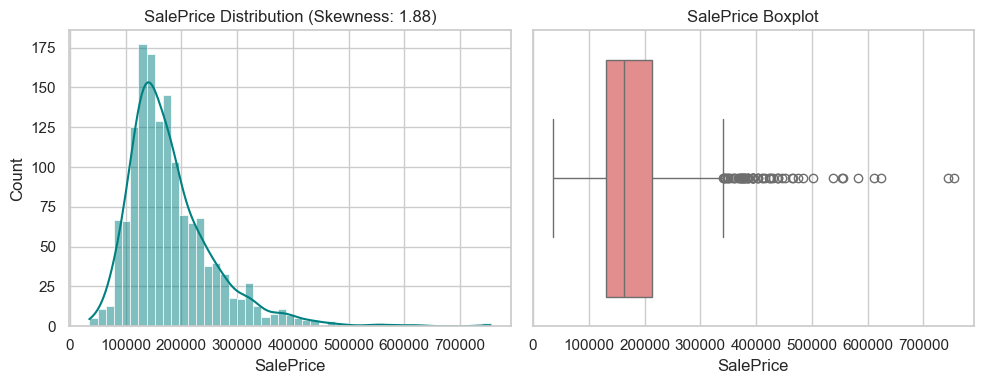

In [3]:
# ----------------- PLOT 1: Target Distribution -----------------
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df[target_col].dropna(), kde=True, color='teal')
plt.title(f"{target_col} Distribution (Skewness: {df[target_col].skew():.2f})")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[target_col], color='lightcoral')
plt.title(f"{target_col} Boxplot")
plt.tight_layout()
plt.show()


## As residuals are hetergenous,but models like lr,log reg assumes homoscadisticity..so make log tranformation.

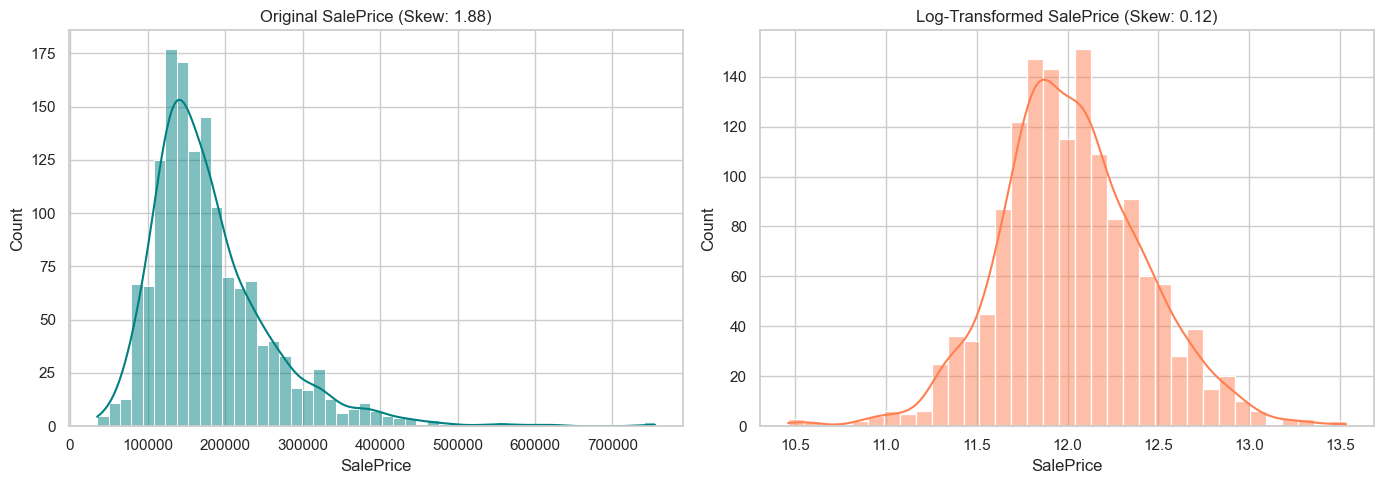

In [4]:


# Compare Original vs Log-Transformed SalePrice
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original
sns.histplot(df['SalePrice'].dropna(), kde=True, ax=axes[0], color='teal')
axes[0].set_title(f"Original SalePrice (Skew: {df['SalePrice'].skew():.2f})")

# Log-Transformed
log_price = np.log1p(df['SalePrice'].dropna())
sns.histplot(log_price, kde=True, ax=axes[1], color='coral')
axes[1].set_title(f"Log-Transformed SalePrice (Skew: {log_price.skew():.2f})")

plt.tight_layout()
plt.show()


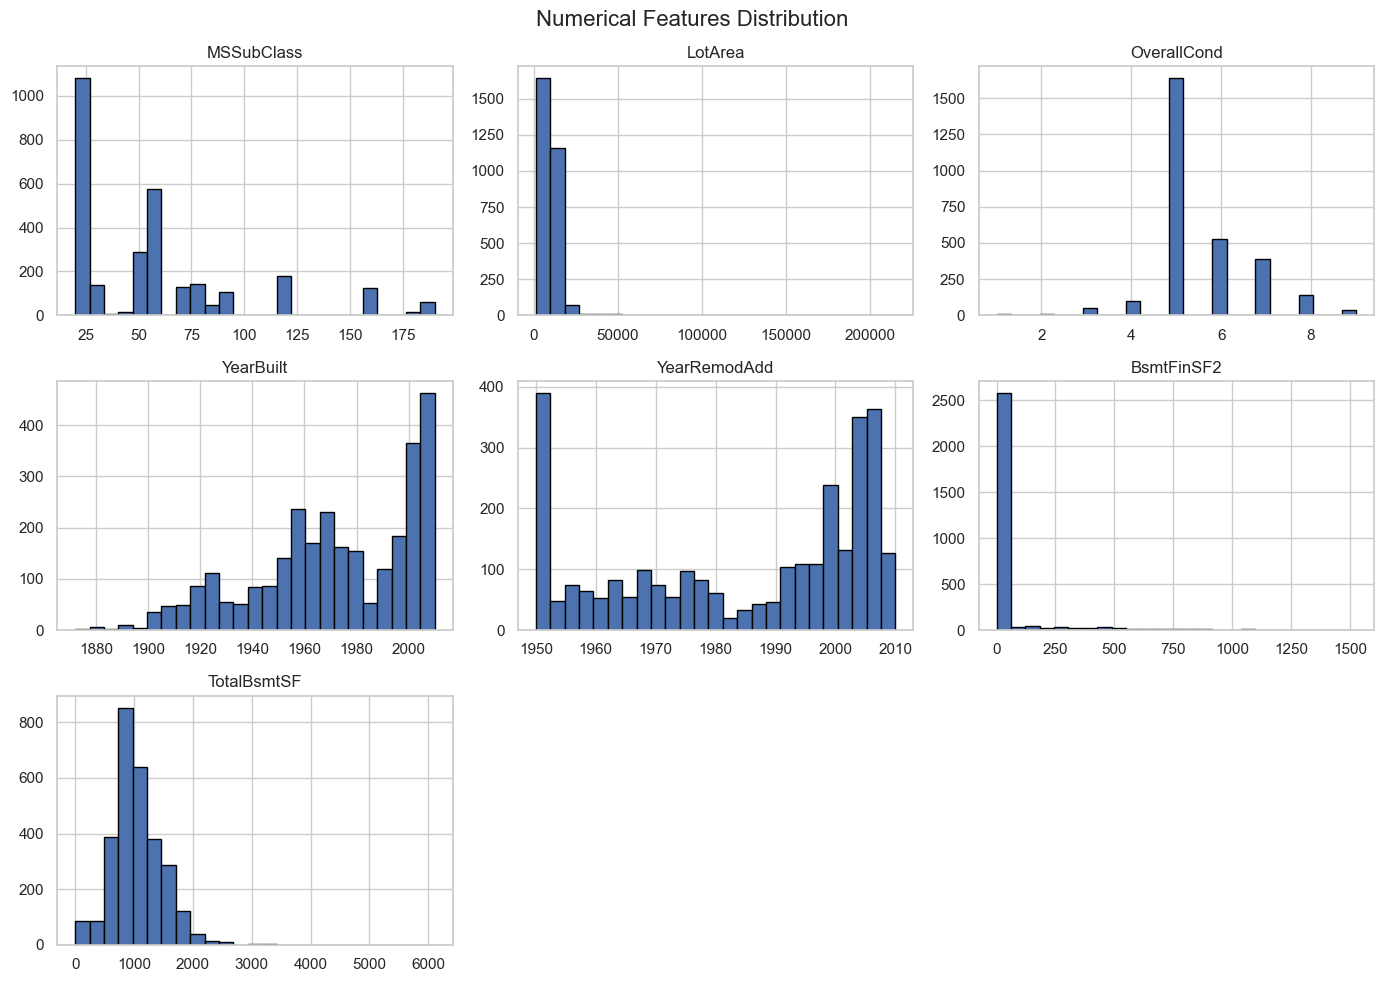

In [5]:

#Numerical Feature Distributions 
df[num_cols].hist(figsize=(14, 10), bins=25, edgecolor="black", color="#4C72B0")
plt.suptitle("Numerical Features Distribution", fontsize=16)
plt.tight_layout()
plt.show()



In [6]:
df['SalePrice']=np.log1p(df['SalePrice'])

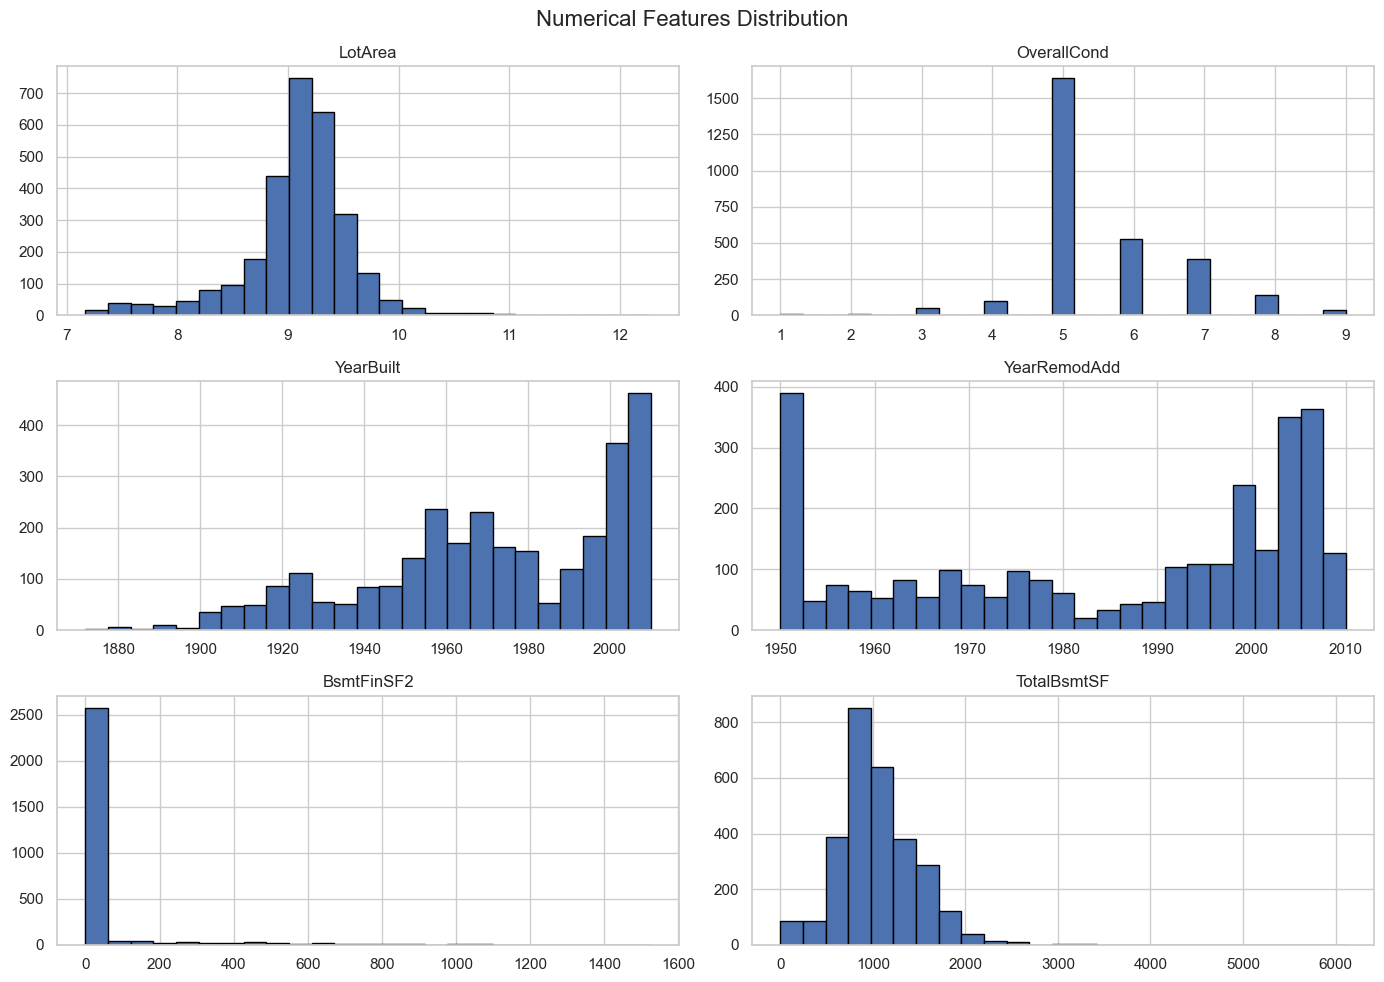

In [7]:
# 1. Convert MSSubClass to Categorical
df['MSSubClass'] = df['MSSubClass'].astype(str)

# 2. Log-transform LotArea
df['LotArea'] = np.log1p(df['LotArea'])

# 3. Create Binary Indicator for BsmtFinSF2
df['Has_BsmtFin2'] = (df['BsmtFinSF2'] > 0).astype(int)

# 4. Feature Engineering->House Age
df['HouseAge'] = df['YearBuilt'].max() - df['YearBuilt']
df['IsRemodeled'] = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)
df[num_cols].hist(figsize=(14, 10), bins=25, edgecolor="black", color="#4C72B0")
plt.suptitle("Numerical Features Distribution", fontsize=16)
plt.tight_layout()
plt.show()


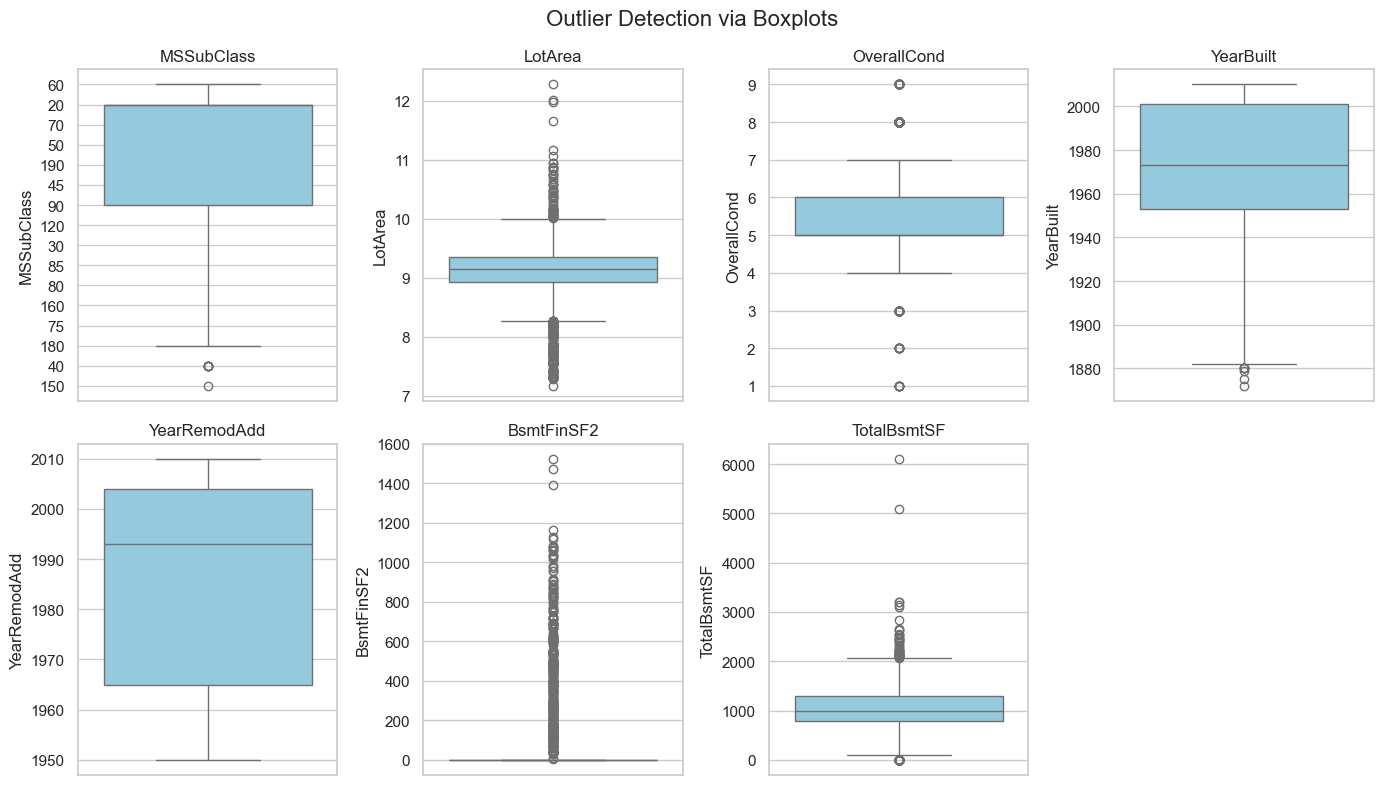

In [8]:
plt.figure(figsize=(14, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot((len(num_cols) + 3) // 4, 4, i)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(col)
plt.suptitle("Outlier Detection via Boxplots", fontsize=16)
plt.tight_layout()
plt.show()

In [9]:
# Drop redundant YearBuilt to remove the -1.00 multicollinearity with HouseAge
df = df.drop(columns=['YearBuilt'])


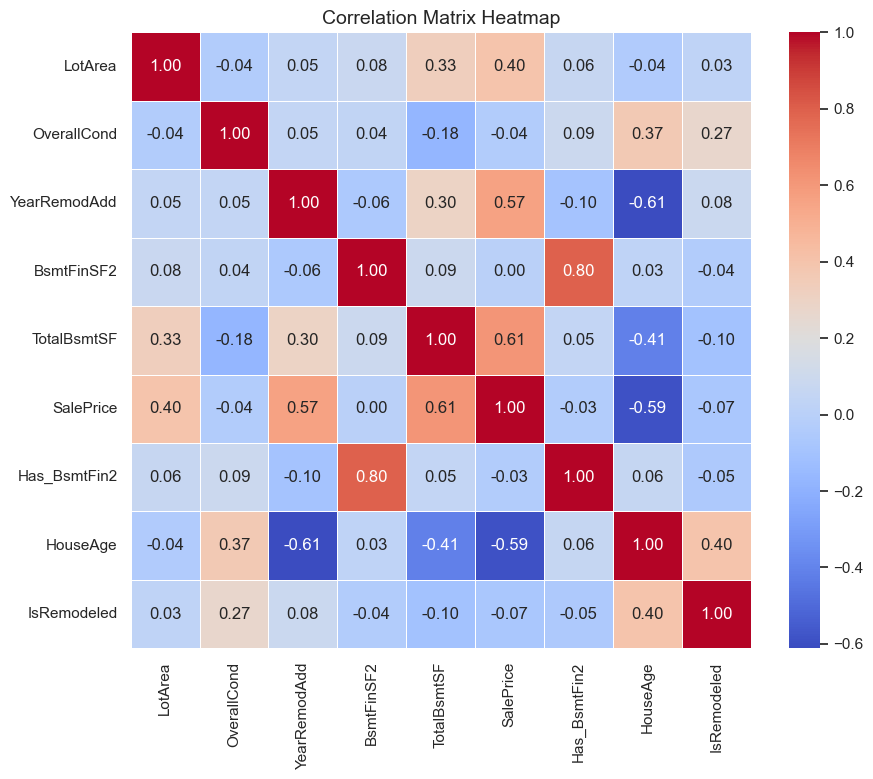

In [10]:
# ----------------- PLOT 4: Correlation Heatmap -----------------
plt.figure(figsize=(10, 8))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix Heatmap", fontsize=14)
plt.show()



C:\Users\harika\AppData\Local\Temp\ipykernel_33668\2252603364.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette="viridis")
C:\Users\harika\AppData\Local\Temp\ipykernel_33668\2252603364.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette="viridis")
C:\Users\harika\AppData\Local\Temp\ipykernel_33668\2252603364.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette="viridis")
C:\Users\harika\AppData\Local\Temp\ipykernel_33668\2252

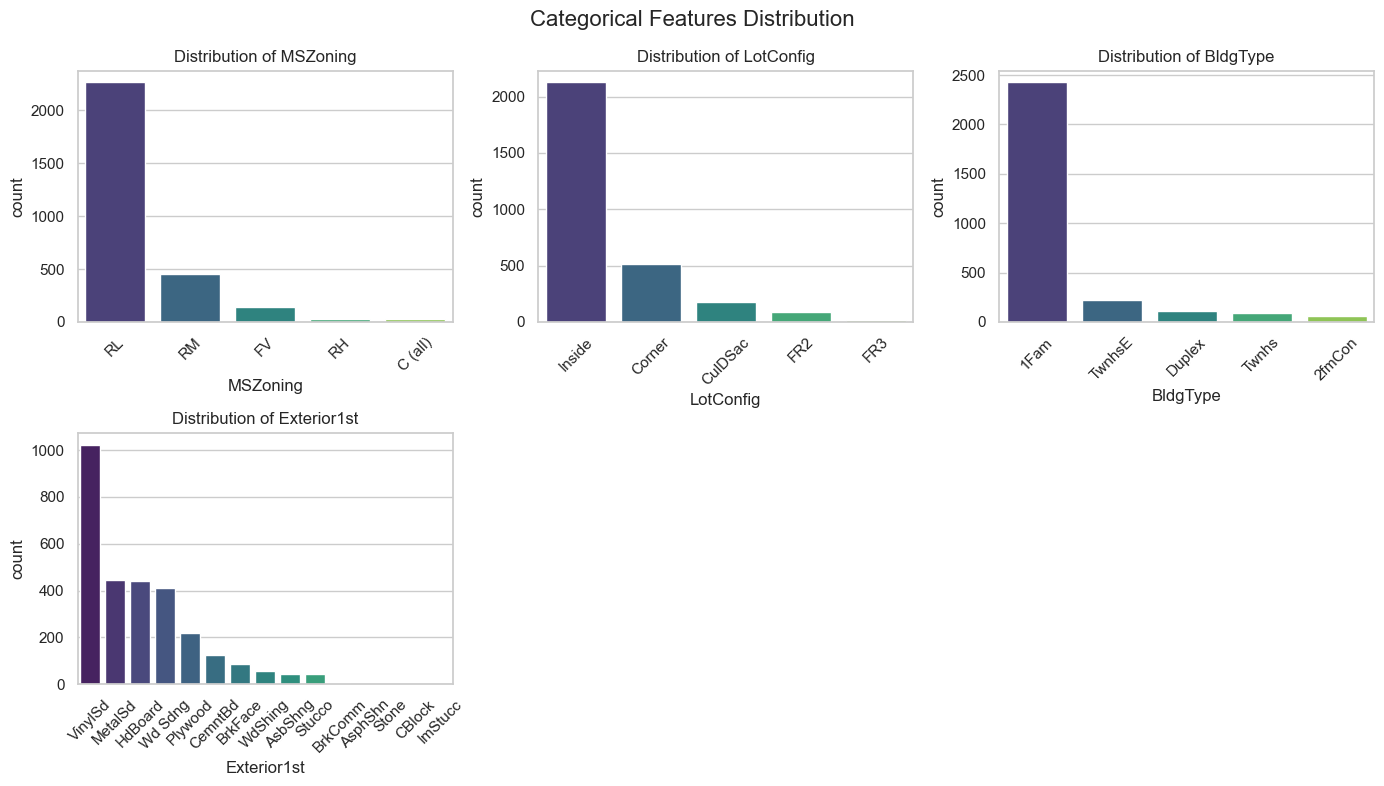

In [11]:
#  Categorical Feature Counts 
if len(cat_cols) > 0:
    plt.figure(figsize=(14, 8))
    for i, col in enumerate(cat_cols, 1):
        plt.subplot((len(cat_cols) + 2) // 3, 3, i)
        order = df[col].value_counts().index
        sns.countplot(data=df, x=col, order=order, palette="viridis")
        plt.title(f"Distribution of {col}")
        plt.xticks(rotation=45)
    plt.suptitle("Categorical Features Distribution", fontsize=16)
    plt.tight_layout()
    plt.show()

In [12]:

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor



In [13]:
# DATA PREPARATION -Handling Missing Target & Splitting
# Drop rows where target variable is NaN

df = df.dropna(subset=[target_col]).reset_index(drop=True)

X = df.drop(columns=[target_col])
y = df[target_col]

# Identify numerical and categorical columns
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical Features ({len(num_features)}): {num_features}")
print(f"Categorical Features ({len(cat_features)}): {cat_features}")




Numerical Features (8): ['LotArea', 'OverallCond', 'YearRemodAdd', 'BsmtFinSF2', 'TotalBsmtSF', 'Has_BsmtFin2', 'HouseAge', 'IsRemodeled']
Categorical Features (5): ['MSSubClass', 'MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']


In [14]:
# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [15]:

#  Sequential & Parallel Preprocessing via Pipelines
# 1. Numerical Pipeline: Impute -> Scaling
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())  # RobustScaler or StandardScaler
])

# 2. Categorical Pipeline: Impute -> One-Hot Encoding
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Handle missing categories
    ('encoder', OneHotEncoder(
        min_frequency=0.01,        # Groups categories with < 1% occurrence into 'infrequent'
        handle_unknown='ignore',   
        sparse_output=False       
    ))
])

# 3. Parallel Processing for Numerical & Categorical Columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ],
    remainder='drop' 
)



In [16]:

# Training & Comparing Various Machine Learning Algorithms

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.0005, max_iter=5000),
    "Support Vector Regressor": SVR(C=1000, epsilon=0.1),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=150, random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(n_estimators=150, learning_rate=0.08, random_state=42),
    "XGBoost Regressor": XGBRegressor(n_estimators=150, learning_rate=0.08, random_state=42, verbosity=0)
}

results = []
cv = KFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model in models.items():
    # Complete Pipeline: Preprocessing + Estimator
    full_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # 5-Fold Cross Validation on Training Data (Negative RMSE -> Positive RMSE)
    cv_scores = cross_val_score(
        full_pipeline, X_train, y_train, 
        cv=cv, scoring='neg_root_mean_squared_error'
    )
    cv_rmse = -cv_scores.mean()

    # Fit on Full Training Set and Evaluate on Test Set
    full_pipeline.fit(X_train, y_train)
    y_pred = full_pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": model_name,
        "CV RMSE (5-Fold)": round(cv_rmse, 2),
        "Test MAE": round(mae, 2),
        "Test RMSE": round(rmse, 2),
        "Test R2 Score": round(r2, 4)
    })

# Results Comparison Table
results_df = pd.DataFrame(results).sort_values(by="Test R2 Score", ascending=False).reset_index(drop=True)
print("\n" + "="*70)
print("              MODEL PERFORMANCE COMPARISON TABLE")
print("="*70)
print(results_df.to_string(index=False))


              MODEL PERFORMANCE COMPARISON TABLE
                      Model  CV RMSE (5-Fold)  Test MAE  Test RMSE  Test R2 Score
Gradient Boosting Regressor              0.17      0.12       0.18         0.8287
    Random Forest Regressor              0.18      0.12       0.18         0.8279
          XGBoost Regressor              0.18      0.13       0.18         0.8246
          Linear Regression              0.20      0.15       0.20         0.7924
           Ridge Regression              0.20      0.15       0.20         0.7893
   Support Vector Regressor              0.22      0.14       0.20         0.7845
           Lasso Regression              0.20      0.15       0.20         0.7791


In [17]:
# 1. DEFINE HYPERPARAMETER GRIDS

# A. Gradient Boosting Grid
gb_param_grid = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__learning_rate': [0.03, 0.05, 0.1],
    'regressor__max_depth': [3, 4, 5],
    'regressor__subsample': [0.8, 1.0],
    'regressor__min_samples_split': [2, 5]
}
# B. XGBoost Grid
xgb_param_grid = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__learning_rate': [0.03, 0.05, 0.1],
    'regressor__max_depth': [3, 4, 6],
    'regressor__colsample_bytree': [0.7, 0.8, 1.0],
    'regressor__subsample': [0.7, 0.8, 1.0]
}
# C. Random Forest Grid
rf_param_grid = {
    'regressor__n_estimators': [150, 250, 350],
    'regressor__max_depth': [10, 15, 20, None],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__max_features': ['sqrt', 'log2', 1.0]
}


In [18]:
# Models & Grids to Tune
models_to_tune = [
    ("Tuned Gradient Boosting", GradientBoostingRegressor(random_state=42), gb_param_grid),
    ("Tuned XGBoost", XGBRegressor(random_state=42, verbosity=0), xgb_param_grid),
    ("Tuned Random Forest", RandomForestRegressor(random_state=42), rf_param_grid)
]


In [19]:

# 2.RANDOMIZED SEARCH CV & EVALUATE
from sklearn.model_selection import RandomizedSearchCV
tuned_results = []
best_fitted_models = {}
print("Starting Hyperparameter Tuning...\n")
for name, model, param_grid in models_to_tune:
    # complete pipeline
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_grid,
        n_iter=20,
        cv=5,
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=-1
    )
    
    # Fit search on training data
    search.fit(X_train, y_train)
    best_pipe = search.best_estimator_
    best_fitted_models[name] = best_pipe
    
    # Evaluate best model on test set
    y_pred = best_pipe.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    tuned_results.append({
        "Model": name,
        "Best CV RMSE": round(-search.best_score_, 4),
        "Test MAE": round(mae, 4),
        "Test RMSE": round(rmse, 4),
        "Test R2 Score": round(r2, 4),
        "Best Params": search.best_params_
    })
    print(f"Completed {name} | Test R2: {r2:.4f}")


Starting Hyperparameter Tuning...

✓ Completed Tuned Gradient Boosting | Test R2: 0.8362
✓ Completed Tuned XGBoost | Test R2: 0.8447
✓ Completed Tuned Random Forest | Test R2: 0.8297


In [20]:
# 3. DISPLAY TUNED RESULTS
tuned_df = pd.DataFrame(tuned_results).sort_values(by="Test R2 Score", ascending=False).reset_index(drop=True)
print("\n" + "="*80)
print("                   TUNED MODEL PERFORMANCE COMPARISON")
print("="*80)
print(tuned_df[['Model', 'Best CV RMSE', 'Test MAE', 'Test RMSE', 'Test R2 Score']].to_string(index=False))

print("\n--- Best Hyperparameters ---")
for res in tuned_results:
    print(f"\n{res['Model']}:")
    for k, v in res['Best Params'].items():
        print(f"  {k.replace('regressor__', '')}: {v}")


                   TUNED MODEL PERFORMANCE COMPARISON
                  Model  Best CV RMSE  Test MAE  Test RMSE  Test R2 Score
          Tuned XGBoost        0.1667    0.1177     0.1702         0.8447
Tuned Gradient Boosting        0.1695    0.1205     0.1748         0.8362
    Tuned Random Forest        0.1785    0.1229     0.1783         0.8297

--- Best Hyperparameters ---

Tuned Gradient Boosting:
  subsample: 0.8
  n_estimators: 200
  min_samples_split: 5
  max_depth: 4
  learning_rate: 0.05

Tuned XGBoost:
  subsample: 0.7
  n_estimators: 300
  max_depth: 4
  learning_rate: 0.03
  colsample_bytree: 0.7

Tuned Random Forest:
  n_estimators: 350
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: 1.0
  max_depth: 15


In [21]:
import joblib

best_model = best_fitted_models["Tuned XGBoost"]

y_test_dollars = np.expm1(y_test)
y_pred_log = best_model.predict(X_test)
y_pred_dollars = np.expm1(y_pred_log)

residuals_dollars = y_test_dollars - y_pred_dollars



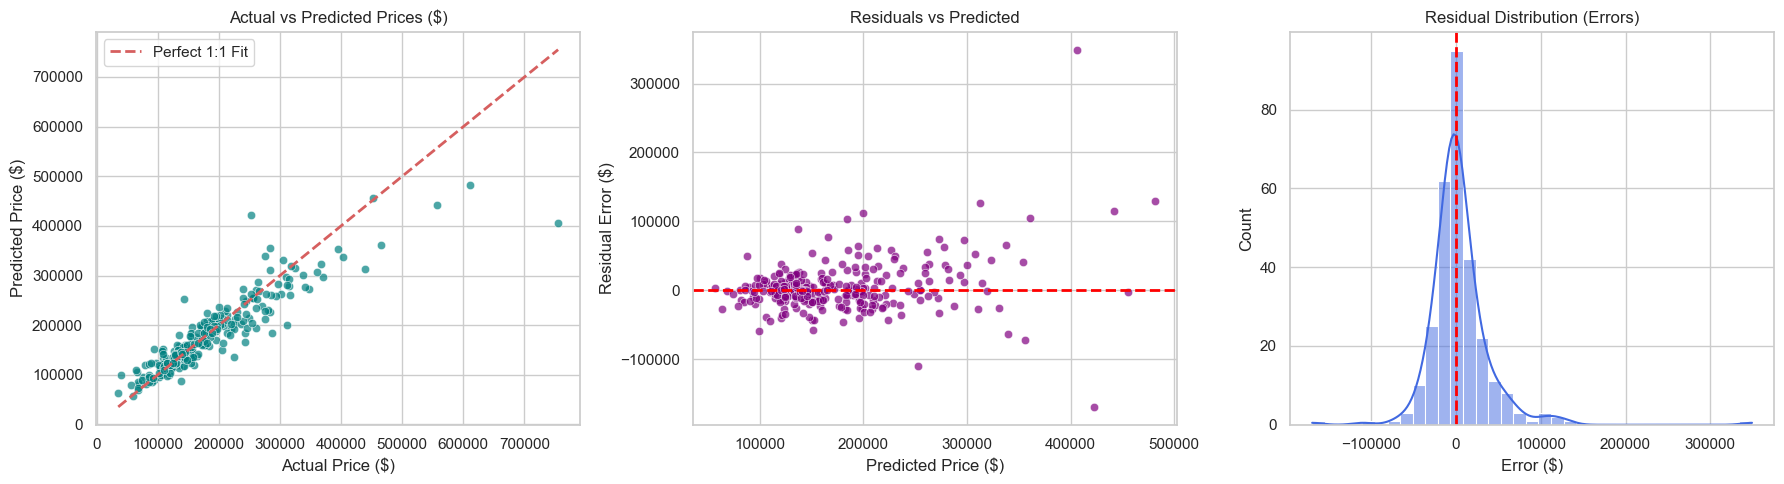

In [22]:
# ----------------- DIAGNOSTIC PLOTS -----------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Actual vs Predicted
sns.scatterplot(x=y_test_dollars, y=y_pred_dollars, alpha=0.7, color='teal', ax=axes[0])
axes[0].plot([y_test_dollars.min(), y_test_dollars.max()], 
             [y_test_dollars.min(), y_test_dollars.max()], 
             'r--', lw=2, label="Perfect 1:1 Fit")
axes[0].set_title(f"Actual vs Predicted Prices ($)")
axes[0].set_xlabel("Actual Price ($)")
axes[0].set_ylabel("Predicted Price ($)")
axes[0].legend()

# Plot 2: Residuals vs Predicted (Homoscedasticity Check)
sns.scatterplot(x=y_pred_dollars, y=residuals_dollars, alpha=0.7, color='purple', ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_title("Residuals vs Predicted")
axes[1].set_xlabel("Predicted Price ($)")
axes[1].set_ylabel("Residual Error ($)")

# Plot 3: Residual Error Distribution
sns.histplot(residuals_dollars, kde=True, color='royalblue', ax=axes[2])
axes[2].axvline(0, color='red', linestyle='--', lw=2)
axes[2].set_title("Residual Distribution (Errors)")
axes[2].set_xlabel("Error ($)")

plt.tight_layout()
plt.show()


In [23]:
import pickle
from pathlib import Path

file_path = Path.cwd() / "house_price_champion_pipeline.pkl"

with open(file_path, "wb") as f:
    pickle.dump(best_model, f)

print(f"✓ Model successfully saved to: {file_path}")


✓ Model successfully saved to: H:\skin_reg\house_price_prediction_reg\house_price_champion_pipeline.pkl
